# US honey supply and pricing: a supply-side test of the Honey Reserve brief

The concept promised named varietals, small-batch sourcing and seasonal drops.
All three are claims about supply. This tests them against USDA production
and price records for 2015 to 2023.

**Findings.**
1. Five states produce 52 to 62% of US honey, and the same seven states are
   the only ones ever in that top five. Supply is concentrated and stable.
2. Price received falls as production scale rises. What first looks like a
   premium for low-yielding, distinctive-honey states turns out to be a
   scale effect: once production volume is controlled for, yield explains
   nothing. There is no varietal price signal at wholesale.

Data: USDA NASS Quick Stats, survey series only. Public domain.

In [11]:
import json

import sqlite3

from datetime import date

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import statsmodels.formula.api as smf

try:

    from google.colab import userdata

    API_KEY = userdata.get("NASS_API_KEY")

except Exception:

    from getpass import getpass

    API_KEY = getpass("USDA Quick Stats key: ")

START_YEAR = 2015

END_YEAR = 2023

SERIES = {

    "HONEY - PRODUCTION, MEASURED IN LB": "production_lb",

    "HONEY - PRODUCTION, MEASURED IN LB / COLONY": "yield_lb_colony",

    "HONEY - PRODUCTION, MEASURED IN $": "value_usd",

    "HONEY - PRICE RECEIVED, MEASURED IN $ / LB": "price_usd_lb",

    "HONEY, BEE COLONIES - INVENTORY, MEASURED IN COLONIES": "colonies",

}

PRICE_CENTS = "HONEY - PRICE RECEIVED, MEASURED IN CENTS / LB"

In [12]:
def fetch_quickstats(**filters) -> pd.DataFrame:

    """Pull one Quick Stats query as a dataframe."""

    params = {"key": API_KEY, "format": "CSV", **filters}

    url = "https://quickstats.nass.usda.gov/api/api_GET/?" + "&".join(

        f"{k}={v}" for k, v in params.items()

    )

    return pd.read_csv(url, low_memory=False)

raw = fetch_quickstats(

    commodity_desc="HONEY",

    agg_level_desc="STATE",

    year__GE=START_YEAR,

)

raw["val"] = pd.to_numeric(

    raw["Value"].astype(str).str.replace(",", ""), errors="coerce"

)

print(f"{len(raw):,} rows, {raw['short_desc'].nunique()} distinct series")

27,209 rows, 23 distinct series


## Two things to check before trusting any of it

**Census against survey.** Quick Stats mixes two collection methods. The
Census of Agriculture is a full count taken every five years; the annual
figures come from a sample survey. They use different coverage and rounding,
so a census year is not comparable with the years either side of it. Keeping
both would show Alabama gaining 4,700 colonies in 2017 purely from a change
of method.

**Reporting lag.** Recent years look like a collapse in production. They are
not. USDA has not finished publishing them.

In [13]:
print(raw.groupby(["source_desc", "year"]).size().unstack(fill_value=0))

year         2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  \
source_desc                                                                     
CENSUS          0     0   300     0     0     0     0   300     0     0     0   
SURVEY       2638  2638  2635  2638  2039  2627  2633  2577  2578  1842  1218   

year         2026  
source_desc        
CENSUS          0  
SURVEY        546  


Census rows appear only in 2017 and 2022, confirming the first concern.
Survey row counts fall off sharply after 2023, confirming the second.
Everything below uses survey rows only, up to 2023.

In [14]:
survey = raw[(raw["source_desc"] == "SURVEY") & raw["short_desc"].isin(SERIES)]

wide = (

    survey.pivot_table(

        index=["state_alpha", "year"],

        columns="short_desc",

        values="val",

        aggfunc="first",

    )

    .rename(columns=SERIES)

    .reset_index()

    .rename_axis(None, axis=1)

)

print(wide.shape)

print(wide.isna().sum())

(499, 7)
state_alpha          0
year                 0
price_usd_lb       213
value_usd           90
production_lb       90
yield_lb_colony     90
colonies             0
dtype: int64


## Repairing the price column

Price is missing on nearly half the rows, and the missingness is not random.
USDA publishes the same figure in two units, dollars per lb and cents per lb,
and which one appears varies by state and year. Pulling the cents series and
dividing by 100 recovers most of the gap.

The two are only interchangeable if they agree where they overlap, so that
gets checked rather than assumed.

In [15]:
cents = raw[(raw["short_desc"] == PRICE_CENTS) & (raw["source_desc"] == "SURVEY")]
from_cents = (
    cents.groupby(["state_alpha", "year"])["val"].first() / 100
).rename("price_from_cents")

wide = wide.merge(from_cents, on=["state_alpha", "year"], how="left")

overlap = wide[wide["price_usd_lb"].notna() & wide["price_from_cents"].notna()]
print(f"rows carrying both units: {len(overlap)}")
print(f"raw cents values range from {cents['val'].min():.0f} to {cents['val'].max():.0f}")

check = wide.dropna(subset=["price_from_cents", "value_usd", "production_lb"]).copy()
check["implied"] = check["value_usd"] / check["production_lb"]
diff = (check["price_from_cents"] - check["implied"]).abs()
print(f"\n{len(check)} rows checkable against value / production")
print(f"median absolute difference: {diff.median():.3f}")
print(f"90th percentile: {diff.quantile(0.9):.3f}")

before = wide["price_usd_lb"].isna().sum()
wide["price_usd_lb"] = wide["price_usd_lb"].fillna(wide["price_from_cents"])
print(f"\nprice missing: {before} -> {wide['price_usd_lb'].isna().sum()} of {len(wide)}")

rows carrying both units: 0
raw cents values range from 153 to 874

123 rows checkable against value / production
median absolute difference: 0.000
90th percentile: 0.001

price missing: 213 -> 90 of 499


Verified identical across 123 overlapping records, so the fill is sound.

The 90 rows still missing price are also missing production, value and yield,
while colony counts are complete. Those are state-years where USDA recorded
hives but published no honey figures, so they drop out cleanly.

In [16]:
gaps = wide[wide["price_usd_lb"].isna()]

print(gaps[["value_usd", "production_lb", "yield_lb_colony", "colonies"]].isna().sum())

value_usd          90
production_lb      90
yield_lb_colony    90
colonies            0
dtype: int64


In [17]:
panel = (

    wide.dropna(subset=["production_lb"])

    .drop(columns=["price_from_cents"])

    .query("year <= @END_YEAR")

    .reset_index(drop=True)

)

print(panel.shape)

print(panel.groupby("year").size())

(367, 7)
year
2015    41
2016    41
2017    41
2018    41
2019    41
2020    41
2021    41
2022    40
2023    40
dtype: int64


## Finding 1: supply is concentrated in a fixed set of states

In [18]:
panel["share"] = panel.groupby("year")["production_lb"].transform(lambda s: s / s.sum())

top5 = (

    panel.sort_values(["year", "share"], ascending=[True, False])

    .groupby("year")

    .head(5)

)

concentration = top5.groupby("year")["share"].sum()

print(concentration.round(3))

print("\nappearances in the top five:")

print(top5["state_alpha"].value_counts())

year
2015    0.560
2016    0.566
2017    0.545
2018    0.588
2019    0.595
2020    0.577
2021    0.523
2022    0.526
2023    0.617
Name: share, dtype: float64

appearances in the top five:
state_alpha
ND    9
SD    8
MT    8
CA    8
FL    7
TX    4
MN    1
Name: count, dtype: int64


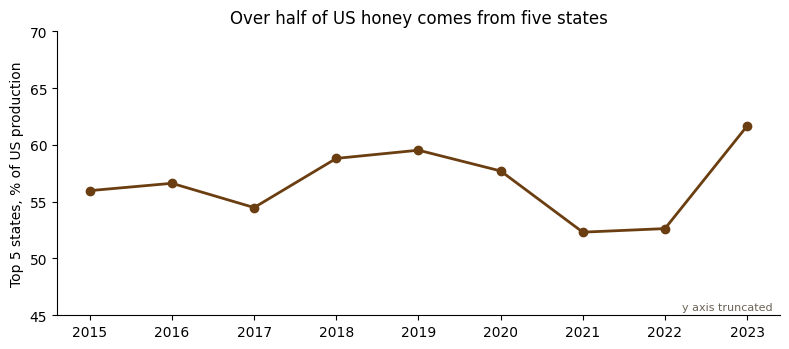

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.6))

ax.plot(concentration.index, concentration * 100, color="#6B3E11", lw=2, marker="o")

ax.set_ylim(45, 70)

ax.set_ylabel("Top 5 states, % of US production")

ax.set_title("Over half of US honey comes from five states")

ax.annotate("y axis truncated", xy=(0.99, 0.02), xycoords="axes fraction",

            ha="right", fontsize=8, color="#6B6355")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

## State summary

One table, used for the reliability view and the dashboard export. Yield per
colony is already normalised by hive count, so it compares a large state with
a small one fairly. Volatility is the standard deviation over the period
divided by the mean, which makes states of different scale comparable.

In [20]:
summary = (

    panel.groupby("state_alpha")

    .agg(

        mean_yield=("yield_lb_colony", "mean"),

        sd_yield=("yield_lb_colony", "std"),

        years_reported=("yield_lb_colony", "count"),

        mean_production=("production_lb", "mean"),

        mean_price=("price_usd_lb", "mean"),

    )

    .query("years_reported >= 7")

)

summary["cv_yield"] = summary["sd_yield"] / summary["mean_yield"]

summary["share"] = summary["mean_production"] / summary["mean_production"].sum()

slopes = {

    code: float(np.polyfit(g["year"], g["yield_lb_colony"], 1)[0])

    for code, g in panel.dropna(subset=["yield_lb_colony"]).groupby("state_alpha")

    if len(g) >= 5

}

summary["yield_slope"] = summary.index.map(slopes)

summary.sort_values("share", ascending=False).round(3).head(15)

,mean_yield,sd_yield,years_reported,mean_production,mean_price,cv_yield,share,yield_slope
state_alpha,,,,,,,,
ND,70.111,8.207,9,3.528278e+07,1.896,0.117,0.240,-1.367
SD,61.000,14.841,9,1.529556e+07,1.976,0.243,0.104,-0.233
CA,39.111,5.487,9,1.239222e+07,2.143,0.140,0.084,0.667
MT,77.111,11.741,9,1.079678e+07,1.977,0.152,0.074,-1.350
FL,44.222,6.996,9,8.953667e+06,2.524,0.158,0.061,-2.233
TX,57.667,10.235,9,7.702778e+06,2.396,0.177,0.052,-3.233
MN,58.889,4.729,9,6.895556e+06,2.092,0.080,0.047,-1.333
MI,50.111,6.528,9,4.468889e+06,2.708,0.130,0.030,-0.900
LA,72.667,16.500,9,3.226889e+06,2.408,0.227,0.022,-5.850


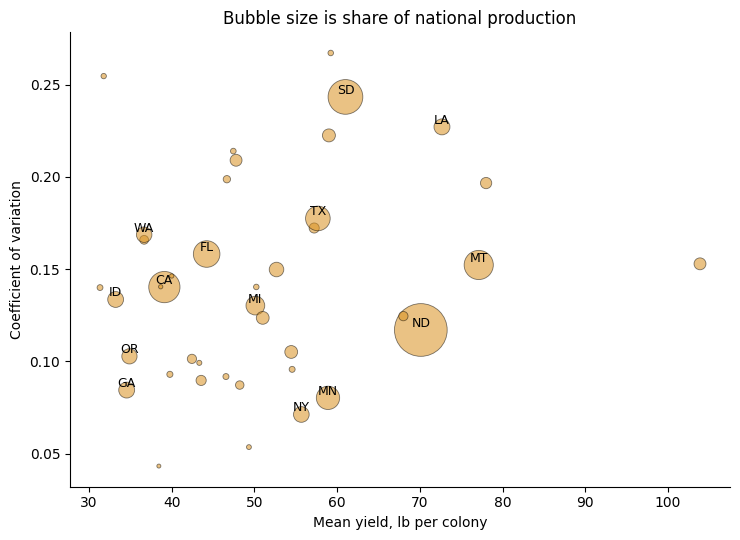

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(summary["mean_yield"], summary["cv_yield"], s=summary["share"] * 6000,

           alpha=.55, color="#D9911F", edgecolor="#14100B", linewidth=.6)

for code, r in summary[summary["share"] > 0.02].iterrows():

    ax.annotate(code, (r["mean_yield"], r["cv_yield"]), ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Mean yield, lb per colony")

ax.set_ylabel("Coefficient of variation")

ax.set_title("Bubble size is share of national production")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

## Finding 2: the apparent flavour premium is a scale effect

California and Florida, the states behind the varietals the brief names, have
the lowest yields of the major producers but earn more per pound. That looks
like the market already pricing distinctiveness.

It isn't. Small states sell direct at close to retail; the Northern Plains
sells by the drum to packers. Adding production volume to the model should
absorb the yield effect if scale is what's really driving price.

In [22]:
model_data = summary.assign(log_prod=np.log(summary["mean_production"])).dropna(

    subset=["mean_price", "mean_yield", "log_prod"]

)

simple = smf.ols("mean_price ~ mean_yield", data=model_data).fit()

controlled = smf.ols("mean_price ~ mean_yield + log_prod", data=model_data).fit()

print("yield alone")

print(simple.summary().tables[1])

print("\nyield with production volume controlled")

print(controlled.summary().tables[1])

yield alone
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1558      0.688      7.491      0.000       3.764       6.548
mean_yield    -0.0366      0.013     -2.815      0.008      -0.063      -0.010

yield with production volume controlled
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.2271      1.493      9.530      0.000      11.205      17.249
mean_yield    -0.0155      0.010     -1.599      0.118      -0.035       0.004
log_prod      -0.7127      0.111     -6.421      0.000      -0.937      -0.488


The yield coefficient goes from -0.037 (p = 0.008) to -0.016 (p = 0.12),
no longer distinguishable from zero, while log production comes in at -0.71
with p below 0.001. Scale explains price; yield was standing in for scale.

Roughly, a tenfold increase in a state's production costs about $1.64 per
pound in price received.

In [23]:
without_hi = model_data.drop("HI", errors="ignore")

print(smf.ols("mean_price ~ mean_yield + log_prod", data=without_hi).fit().summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.2411      1.502      9.483      0.000      11.198      17.284
mean_yield    -0.0100      0.012     -0.819      0.418      -0.035       0.015
log_prod      -0.7320      0.115     -6.390      0.000      -0.964      -0.500


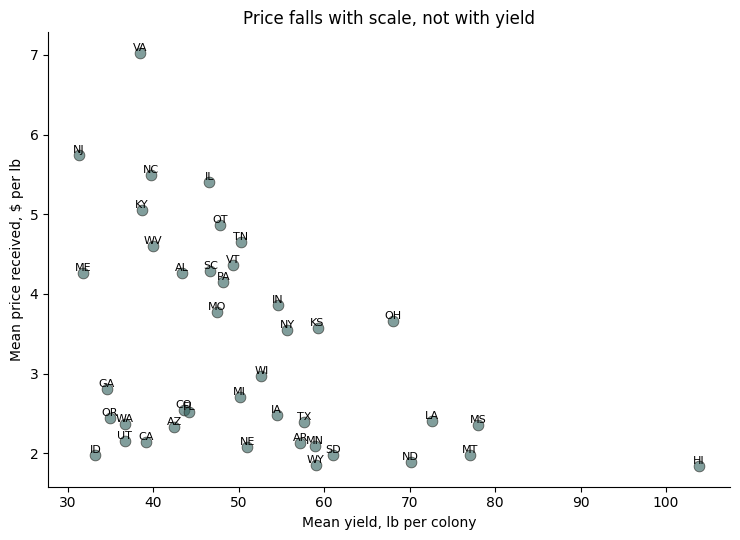

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(model_data["mean_yield"], model_data["mean_price"], alpha=.6,

           color="#2E5E5A", edgecolor="#14100B", linewidth=.6, s=60)

for code, r in model_data.iterrows():

    ax.annotate(code, (r["mean_yield"], r["mean_price"]),

                fontsize=8, ha="center", va="bottom")

ax.set_xlabel("Mean yield, lb per colony")

ax.set_ylabel("Mean price received, $ per lb")

ax.set_title("Price falls with scale, not with yield")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

**Caveat.** Price received is what beekeepers get, not what shoppers pay. The
channel explanation is inference from the pattern, not something USDA states.
With 41 states and one observation each, this is suggestive rather than
decisive.

**What it changes.** The premium the brief wants to capture does not exist
upstream. It would have to be created downstream through packaging, story and
retail position, on honey bought at commodity rates. That is a viable
strategy, and it is what Graza and Carbone do, but it is a different argument
from the one the deck makes.

### Export

The exposure score combines yield volatility with yield direction, weighted
0.67 and 0.33. Those weights are a judgement rather than a result, and they
are written into the output file so a reader can disagree with them
precisely. Colony loss comes from a separate USDA report that is not pulled
here, so those fields stay empty rather than being guessed at.

Hawaii yields 104 lb per colony, roughly a third above the next state, on a
different production system. The robustness check above reruns the model
without it.

In [25]:
con = sqlite3.connect("honey.db")

panel.to_sql("honey", con, if_exists="replace", index=False)

panel.to_csv("honey_panel.csv", index=False)

summary.to_csv("state_summary.csv")

state_names = raw[["state_alpha", "state_name"]].drop_duplicates().set_index("state_alpha")["state_name"]

def normalise(s: pd.Series) -> pd.Series:

    span = s.max() - s.min()

    return (s - s.min()) / span if span else s * 0

WEIGHTS = {"volatility": 0.67, "yield_trend": 0.33}

export = summary.reset_index().rename(columns={"state_alpha": "state_code"})

export["state_name"] = export["state_code"].map(state_names)

export["exposure"] = (

    WEIGHTS["volatility"] * normalise(export["cv_yield"])

    + WEIGHTS["yield_trend"] * normalise(-export["yield_slope"].fillna(0))

)

export["recent_pct_lost"] = None

export["loss_change_pp"] = None

national = (

    panel.groupby("year")

    .agg(production_lb=("production_lb", "sum"),

         colonies=("colonies", "sum"),

         value_usd=("value_usd", "sum"))

    .reset_index()

)

national["yield_lb_colony"] = national["production_lb"] / national["colonies"]

national["price_usd_lb"] = national["value_usd"] / national["production_lb"]

payload = {

    "meta": {

        "generated": date.today().isoformat(),

        "source": f"USDA NASS Quick Stats, survey series, {START_YEAR}-{END_YEAR}",

        "latest_year": END_YEAR,

        "weights": WEIGHTS,

    },

    "national": national.round(3).where(pd.notna(national), None).to_dict("records"),

    "states": export.round(4).where(pd.notna(export), None).to_dict("records"),

}

with open("dashboard.json", "w") as f:

    json.dump(payload, f, indent=1)

print(f"wrote honey.db, honey_panel.csv, state_summary.csv, dashboard.json ({len(export)} states)")

wrote honey.db, honey_panel.csv, state_summary.csv, dashboard.json (41 states)
